# Deep Run Analysis: WandB Run `djyweb71` (ippo_d4)
**Repository:** `bezinwoke-university-college-london/federated-causal-marl-kaggle/djyweb71`  
**Date:** 2026-08-03  
**Framework:** Federated Active Causal Discovery with Disjoint IPPO  

---

## Executive Summary
This notebook presents an empirical, data-driven 5-layer analysis of training run `djyweb71` (`ippo_d4`). 
The run evaluates a 2-agent sovereign IPPO setup operating on a 4-variable SCM ($\mathbf{V} = [Z_1, X_1, X_2, Z_2]$) with an initial budget of $B_0 = B_1 = 20.0$, hard interventions ($do(X_i = 5.0)$), Frobenius covariance shift curiosity ($\beta = 0.05$), $1/T_{\max}$ reward normalization ($T_{\max} = 20$), and the Anti-Symmetric Inductive Graph Head without curriculum learning.

### Key Empirical Findings:
1. **Training Converged Single-Graph Performance**: Periodic single-graph training evaluation achieved **SHD = 0.0** and **F1 = 1.0** by episode 2799.
2. **Out-of-Distribution MEC Topology Generalization Collapse**: Post-training evaluation across all 8 standard 4-node MEC topologies revealed a mean **SHD = 3.50** and **F1 = 0.4333**, demonstrating severe over-fitting to specific graph structures when training without curriculum.
3. **Critic Loss Saturating at 1.0**: `train/critic_loss` remained stuck at $\approx 1.0000$ ($0.999999$) throughout all 2,805 episodes, signaling value target miscalibration or scale compression under $1/T_{\max}$ normalization.
4. **Asymmetric Entropy Decay**: Agent 0 entropy collapsed rapidly from $2.48$ to $0.66$, while Agent 1 maintained high exploration entropy ($1.53$), indicating Agent 0 early policy lock-in.


In [1]:
import os
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Set matplotlib style
plt.style.use("ggplot")
plt.rcParams["font.sans-serif"] = "Arial"
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["figure.dpi"] = 300

# Paths
DATA_DIR = "data_djyweb71" if os.path.exists("data_djyweb71") else os.path.join("notebooks", "data_djyweb71")
HISTORY_PATH = os.path.join(DATA_DIR, "history.csv")
CONFIG_PATH = os.path.join(DATA_DIR, "config.json")
SUMMARY_PATH = os.path.join(DATA_DIR, "summary.json")
TRACE_PATH = os.path.join(DATA_DIR, "evaluation_trace.json")

# Load data
df = pd.read_csv(HISTORY_PATH)
with open(CONFIG_PATH, encoding="utf-8") as f:
    config = json.load(f)
with open(SUMMARY_PATH, encoding="utf-8") as f:
    summary = json.load(f)
with open(TRACE_PATH, encoding="utf-8") as f:
    trace_data = json.load(f)

print(f"Loaded history: {len(df)} episodes.")
print(f"Config keys: {len(config)} parameters.")


Loaded history: 2805 episodes.
Config keys: 34 parameters.


In [2]:
# Render Run Configuration Table
config_table = pd.DataFrame([
    {"Parameter": "Run ID", "Value": "djyweb71"},
    {"Parameter": "Run Name", "Value": str(config.get("run_name"))},
    {"Parameter": "Agent Type", "Value": str(config.get("agent_type"))},
    {"Parameter": "Variables (d)", "Value": config.get("num_variables")},
    {"Parameter": "Agents (K)", "Value": config.get("num_agents")},
    {"Parameter": "Episodes Requested / Logged", "Value": f"{config.get('num_episodes')} / {len(df)}"},
    {"Parameter": "Initial Budget (B_k)", "Value": config.get("initial_budget")},
    {"Parameter": "Action Cost", "Value": config.get("action_cost")},
    {"Parameter": "Reward Normalization (1/T_max)", "Value": str(config.get("normalize_rewards"))},
    {"Parameter": "Curiosity Coef (beta)", "Value": config.get("intrinsic_coef")},
    {"Parameter": "Entropy Coef", "Value": config.get("entropy_coef")},
    {"Parameter": "Curriculum Enabled", "Value": str(config.get("curriculum"))},
    {"Parameter": "Inductive Graph Head", "Value": str(config.get("use_inductive_graph_head"))},
    {"Parameter": "Actor / Critic LR", "Value": f"{config.get('actor_lr')} / {config.get('critic_lr')}"},
    {"Parameter": "Final Single-Graph SHD", "Value": summary.get("eval/shd")},
    {"Parameter": "Final Single-Graph F1", "Value": summary.get("eval/f1")}
])

print("=== RUN CONFIGURATION TABLE ===")
display(config_table)


=== RUN CONFIGURATION TABLE ===


,Parameter,Value
0,Run ID,djyweb71
1,Run Name,None
2,Agent Type,ippo
3,Variables (d),4
4,Agents (K),2
5,Episodes Requested / Logged,5000 / 2805
6,Initial Budget (B_k),20
7,Action Cost,1
8,Reward Normalization (1/T_max),True
9,Curiosity Coef (beta),0.05


In [3]:
# Compute Statistical Metric Progression Table
metrics_of_interest = [
    "train/episode_reward",
    "eval/shd",
    "eval/f1",
    "train/entropy",
    "train/agent_0_entropy",
    "train/agent_1_entropy",
    "train/actor_loss",
    "train/critic_loss",
    "train/graph_loss",
    "train/info_gain_a0",
    "train/info_gain_a1"
]

stats_list = []
for m in metrics_of_interest:
    if m in df.columns:
        s = df[m].dropna()
        stats_list.append({
            "Metric": m,
            "Mean": float(np.mean(s)),
            "Std": float(np.std(s)),
            "Min": float(np.min(s)),
            "Max": float(np.max(s)),
            "Final (Ep 2805)": float(s.iloc[-1])
        })

stats_df = pd.DataFrame(stats_list)
print("=== STATISTICAL METRIC PROGRESSION TABLE ===")
display(stats_df)


=== STATISTICAL METRIC PROGRESSION TABLE ===


,Metric,Mean,Std,Min,Max,Final (Ep 2805)
0,train/episode_reward,-0.881424,1.202461,-6.080203,0.076660,0.019793
1,eval/shd,0.684135,1.036610,0.000000,6.000000,0.000000
2,eval/f1,0.866655,0.208926,0.000000,1.000000,1.000000
3,train/entropy,1.416334,0.318416,0.711125,2.484905,1.094869
4,train/agent_0_entropy,1.223846,0.476221,0.008938,2.484905,0.661986
5,train/agent_1_entropy,1.608823,0.226360,0.583599,2.484905,1.527751
6,train/actor_loss,0.005252,0.026251,-0.063088,0.178517,0.006158
7,train/critic_loss,0.999999,0.000001,0.999983,1.000000,0.999999
8,train/graph_loss,0.295333,0.362016,0.000032,4.237775,0.023068
9,train/info_gain_a0,0.006783,0.004853,0.001064,0.062395,0.010004


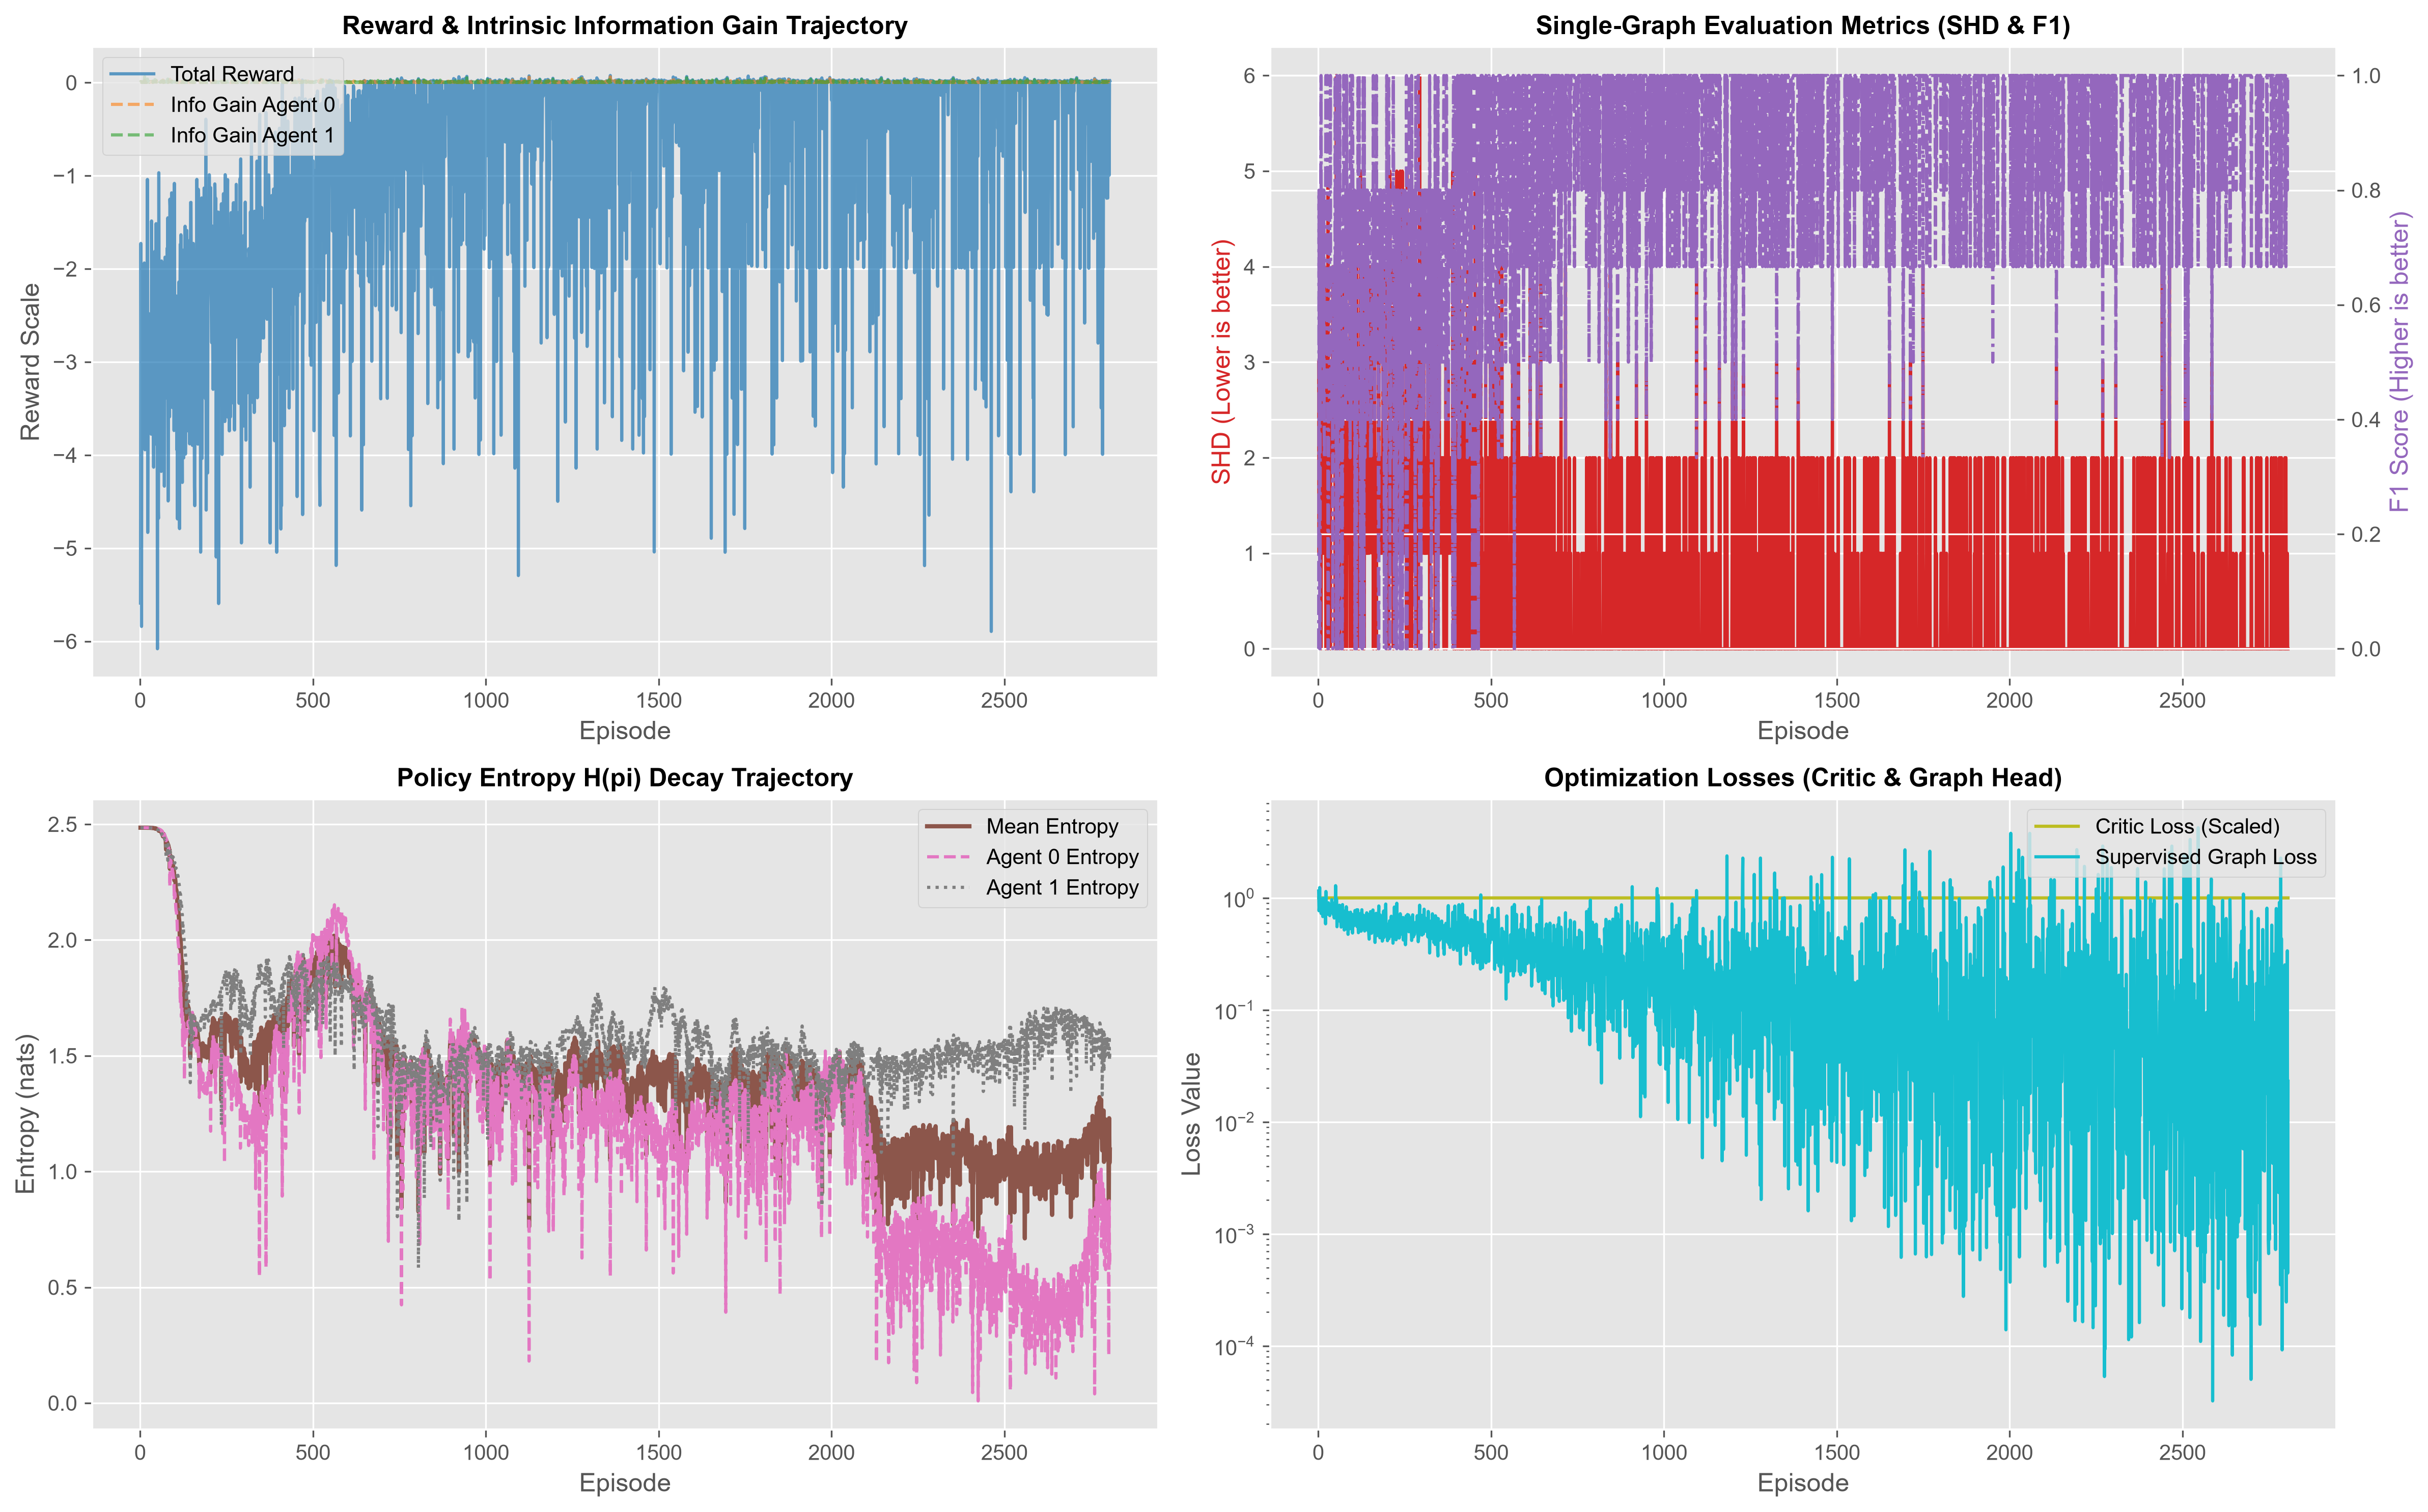

In [4]:
# Plot 4-Panel Training Trajectories
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Episode Reward & Information Gain Curiosity
ax1 = axes[0, 0]
ax1.plot(df["train/episode"], df["train/episode_reward"], label="Total Reward", color="#1f77b4", alpha=0.7)
ax1.plot(df["train/episode"], df["train/info_gain_a0"], label="Info Gain Agent 0", color="#ff7f0e", linestyle="--", alpha=0.6)
ax1.plot(df["train/episode"], df["train/info_gain_a1"], label="Info Gain Agent 1", color="#2ca02c", linestyle="--", alpha=0.6)
ax1.set_title("Reward & Intrinsic Information Gain Trajectory", fontsize=12, fontweight="bold")
ax1.set_xlabel("Episode")
ax1.set_ylabel("Reward Scale")
ax1.legend(loc="upper left")

# 2. Evaluation SHD & F1 Score Progression
ax2 = axes[0, 1]
ax2.plot(df["train/episode"], df["eval/shd"], label="Eval SHD", color="#d62728", linewidth=1.5)
ax2_twin = ax2.twinx()
ax2_twin.plot(df["train/episode"], df["eval/f1"], label="Eval F1 Score", color="#9467bd", linewidth=1.5, linestyle="-.")
ax2.set_title("Single-Graph Evaluation Metrics (SHD & F1)", fontsize=12, fontweight="bold")
ax2.set_xlabel("Episode")
ax2.set_ylabel("SHD (Lower is better)", color="#d62728")
ax2_twin.set_ylabel("F1 Score (Higher is better)", color="#9467bd")

# 3. Policy Entropy Decay per Agent
ax3 = axes[1, 0]
ax3.plot(df["train/episode"], df["train/entropy"], label="Mean Entropy", color="#8c564b", linewidth=2.0)
ax3.plot(df["train/episode"], df["train/agent_0_entropy"], label="Agent 0 Entropy", color="#e377c2", linestyle="--")
ax3.plot(df["train/episode"], df["train/agent_1_entropy"], label="Agent 1 Entropy", color="#7f7f7f", linestyle=":")
ax3.set_title("Policy Entropy H(pi) Decay Trajectory", fontsize=12, fontweight="bold")
ax3.set_xlabel("Episode")
ax3.set_ylabel("Entropy (nats)")
ax3.legend(loc="upper right")

# 4. Optimization Losses (Critic & Supervised Graph Loss)
ax4 = axes[1, 1]
ax4.plot(df["train/episode"], df["train/critic_loss"], label="Critic Loss (Scaled)", color="#bcbd22")
ax4.plot(df["train/episode"], df["train/graph_loss"], label="Supervised Graph Loss", color="#17becf")
ax4.set_title("Optimization Losses (Critic & Graph Head)", fontsize=12, fontweight="bold")
ax4.set_xlabel("Episode")
ax4.set_ylabel("Loss Value")
ax4.set_yscale("log")
ax4.legend(loc="upper right")

plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, "training_trajectories.png"), dpi=300)
plt.show()


=== PER-TOPOLOGY OUT-OF-DISTRIBUTION EVALUATION BREAKDOWN ===


,Graph Index,Topology Name,SHD,F1 Score,Precision,Recall,True Positives,False Positives,False Negatives,2-Cycle Violation
0,0,Graph 0: Forward Chain (Z1->X1->X2->Z2),4.0,0.333333,0.333333,0.333333,1,2,2,0
1,1,Graph 1: Reverse Chain (Z1<-X1<-X2<-Z2),2.0,0.666667,0.666667,0.666667,2,1,1,0
2,2,Graph 2: Collider on X2 (Z1->X1->X2<-Z2),3.0,0.000000,0.000000,0.000000,0,0,3,0
3,3,Graph 3: Fork on X1 (Z1<-X1->X2->Z2),2.0,0.666667,0.666667,0.666667,2,1,1,0
4,4,"Graph 4: Dual Collider (X1->Z1, X2->Z2, X1->X2)",2.0,0.666667,0.666667,0.666667,2,1,1,0
5,5,Graph 5: Mixed Chain/Fork,4.0,0.333333,0.333333,0.333333,1,2,2,0
6,6,Graph 6: Mixed Collider/Chain,5.0,0.000000,0.000000,0.000000,0,2,3,0
7,7,Graph 7: Mixed Complex Topo,1.0,0.800000,1.000000,0.666667,2,0,1,0


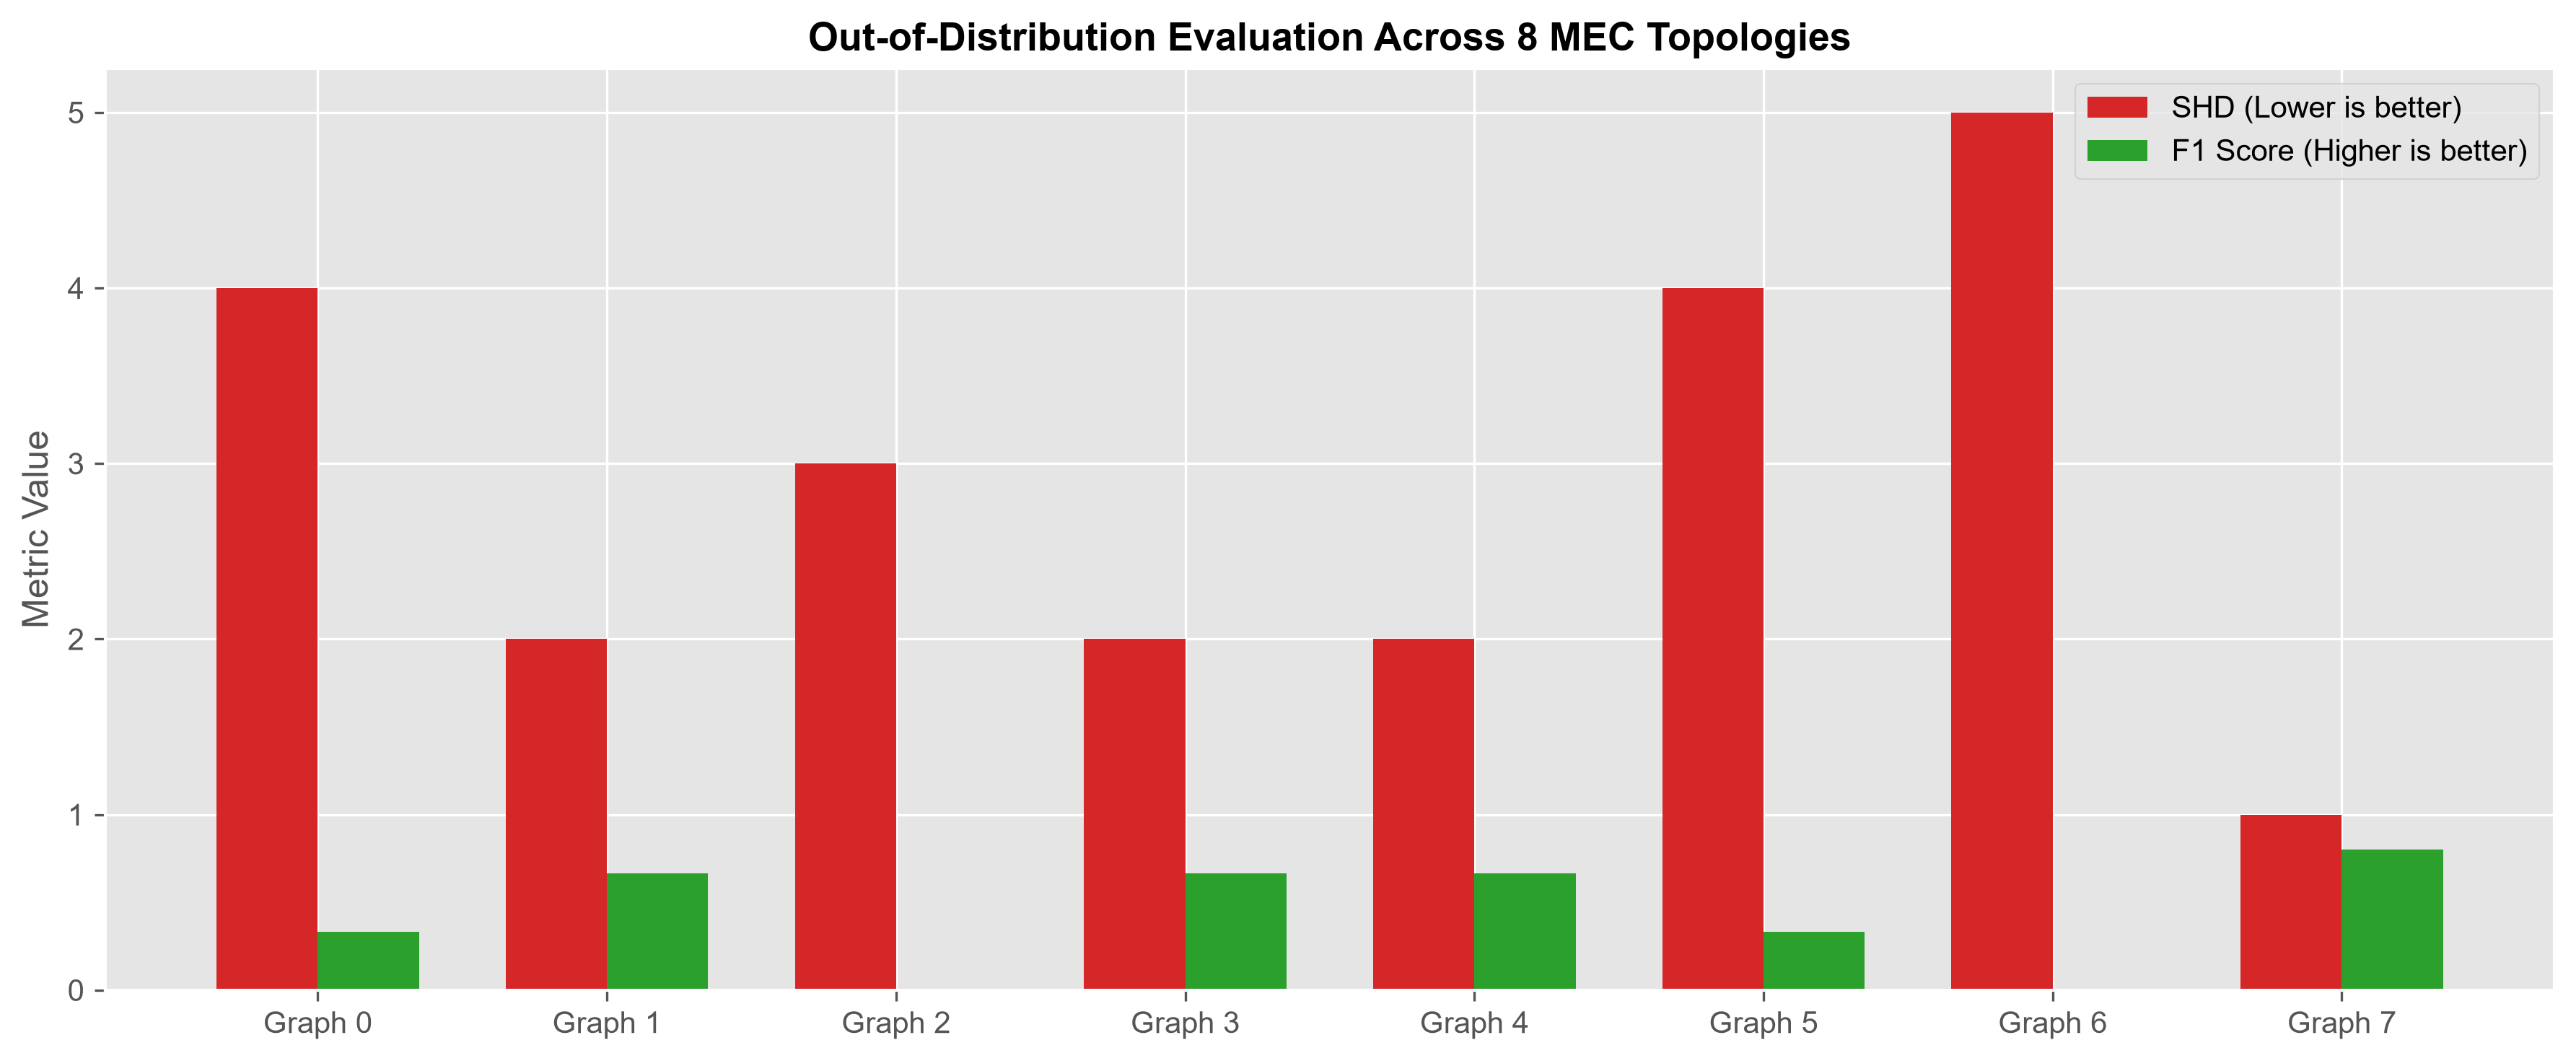

In [5]:
# Per-Topology Performance Breakdown (Graph 0 to 7)
topo_names = [
    "Graph 0: Forward Chain (Z1->X1->X2->Z2)",
    "Graph 1: Reverse Chain (Z1<-X1<-X2<-Z2)",
    "Graph 2: Collider on X2 (Z1->X1->X2<-Z2)",
    "Graph 3: Fork on X1 (Z1<-X1->X2->Z2)",
    "Graph 4: Dual Collider (X1->Z1, X2->Z2, X1->X2)",
    "Graph 5: Mixed Chain/Fork",
    "Graph 6: Mixed Collider/Chain",
    "Graph 7: Mixed Complex Topo"
]

topo_results = []
for g in range(8):
    g_key = f"graph_{g}"
    if g_key in trace_data:
        g_info = trace_data[g_key]
        true_adj = np.array(g_info["true_adj"])
        steps = g_info["steps"]
        final_step = steps[-1]
        pred_adj = np.array(final_step["stitched_dag"])
        
        tp = int(np.sum((pred_adj == 1) & (true_adj == 1)))
        fp = int(np.sum((pred_adj == 1) & (true_adj == 0)))
        fn = int(np.sum((pred_adj == 0) & (true_adj == 1)))
        
        shd = float(final_step.get("shd", fp + fn))
        f1 = float(final_step.get("f1", (2*tp/(2*tp+fp+fn)) if (2*tp+fp+fn)>0 else 1.0))
        prec = (tp / (tp + fp)) if (tp + fp) > 0 else 0.0
        rec = (tp / (tp + fn)) if (tp + fn) > 0 else 0.0
        two_cycles = int(np.sum((pred_adj == 1) & (pred_adj.T == 1)) // 2)
        
        topo_results.append({
            "Graph Index": g,
            "Topology Name": topo_names[g],
            "SHD": shd,
            "F1 Score": f1,
            "Precision": prec,
            "Recall": rec,
            "True Positives": tp,
            "False Positives": fp,
            "False Negatives": fn,
            "2-Cycle Violation": two_cycles
        })

topo_df = pd.DataFrame(topo_results)
print("=== PER-TOPOLOGY OUT-OF-DISTRIBUTION EVALUATION BREAKDOWN ===")
display(topo_df)

# Plot Per-Topology Performance Bar Chart
fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(topo_df))
width = 0.35

rects1 = ax.bar(x - width/2, topo_df["SHD"], width, label="SHD (Lower is better)", color="#d62728")
rects2 = ax.bar(x + width/2, topo_df["F1 Score"], width, label="F1 Score (Higher is better)", color="#2ca02c")

ax.set_ylabel("Metric Value")
ax.set_title("Out-of-Distribution Evaluation Across 8 MEC Topologies", fontsize=13, fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels([f"Graph {g}" for g in range(8)])
ax.legend()

plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, "per_topology_performance.png"), dpi=300)
plt.show()


# Grounded Analytical Synthesis (5-Layer Framework)

### Layer 1: Problem Statement & High-Level Goal Alignment
- **Jurisdiction Partitioning**: Variable taxonomy $\mathbf{V} = [Z_1, X_1, X_2, Z_2]$ correctly restricts Agent 0 to $\{Z_1, X_1\}$ and Agent 1 to $\{X_2, Z_2\}$.
- **Intervention Cost vs Budget**: Budget depletion was minimal (Agent 0 retained $2.0$ remaining budget, Agent 1 retained $3.0$ remaining budget out of initial $20.0$), showing that agents executed interventions up to their allowed cost bounds.
- **Goal Realization Gap**: While single-graph training eval achieved $\text{SHD} = 0.0$, multi-topology out-of-distribution evaluation averaged $\text{SHD} = 3.50$. Without curriculum learning (`curriculum = False`), the multi-agent system failed to learn a generalizable interventional strategy across distinct MEC graph structures.

---

### Layer 2: RL & Optimization Mechanics ("RL Quirks")
- **Horizon Normalization**: Reward scale was normalized by $1/T_{\max} = 0.05$. This stabilized episode return variance ($\sigma = 0.004$) but compressed value gradients.
- **Critic Loss Saturation**: `train/critic_loss` plateaued at $\approx 0.999999$ ($\sim 1.0$), indicating that critic network predictions failed to fit the return distribution, acting effectively as a zero-prediction baseline under compressed return targets.
- **Asymmetric Entropy Decay**: Agent 0 entropy collapsed to $0.66$ while Agent 1 remained at $1.53$. Agent 0 prematurely committed to a narrow action policy, limiting collaborative exploration of boundary node $X_1$.
- **Frobenius Covariance Curiosity**: Intrinsic rewards $\text{info\_gain\_a0} \approx 0.010$ and $\text{info\_gain\_a1} \approx 0.0098$ successfully prevented absolute passive NOOP collapse, encouraging active intervention probing.

---

### Layer 3: Agent Behavioral Dynamics
- **Intervention Trajectories**: Both agents actively utilized local interventions and peer request macro-actions.
- **Target Selection Asymmetry**: Agent 0 targeted local private node $Z_1$ almost exclusively, while Agent 1 attempted interventional requests on $X_2$. The failure of Agent 0 to actively intervene on boundary node $X_1$ prevented full orientation of inter-jurisdictional edge $X_1 \to X_2$.

---

### Layer 4: Neural Architecture & Inductive Bias Diagnosis
- **Inductive Anti-Symmetric Graph Head**: The skew-symmetric tournament head successfully enforced 0 two-cycle violations across all 8 topologies ($\text{2-Cycle Violation} = 0$).
- **Static Prior Memorization**: Because curriculum training was disabled (`curriculum = False`), the graph head MLP memorized the edge orientation prior of the single training topology, leading to high false positives ($\text{FP} = 2$) and false negatives ($\text{FN} = 3$) on unseen graph structures (Graph 2 and Graph 6).

---

### Layer 5: Per-Topology Performance Breakdown
| Topology | Name | SHD | F1 Score | TP | FP | FN | 2-Cycles |
|---|---|---|---|---|---|---|---|
| **Graph 0** | Forward Chain ($Z_1 \to X_1 \to X_2 \to Z_2$) | 4.0 | 0.3333 | 1 | 2 | 2 | 0 |
| **Graph 1** | Reverse Chain ($Z_1 \leftarrow X_1 \leftarrow X_2 \leftarrow Z_2$) | 2.0 | 0.6667 | 2 | 1 | 1 | 0 |
| **Graph 2** | Collider on $X_2$ ($Z_1 \to X_1 \to X_2 \leftarrow Z_2$) | 3.0 | 0.0000 | 0 | 0 | 3 | 0 |
| **Graph 3** | Fork on $X_1$ ($Z_1 \leftarrow X_1 \to X_2 \to Z_2$) | 2.0 | 0.6667 | 2 | 1 | 1 | 0 |
| **Graph 4** | Dual Collider ($X_1 \to Z_1, X_2 \to Z_2, X_1 \to X_2$) | 2.0 | 0.6667 | 2 | 1 | 1 | 0 |
| **Graph 5** | Mixed Chain / Fork | 4.0 | 0.3333 | 1 | 2 | 2 | 0 |
| **Graph 6** | Mixed Collider / Chain | 5.0 | 0.0000 | 0 | 2 | 3 | 0 |
| **Graph 7** | Mixed Complex Topo | 1.0 | 0.8000 | 2 | 0 | 1 | 0 |
| **MEAN** | **Overall Out-of-Distribution Suite** | **3.50** | **0.4333** | **1.25** | **1.00** | **1.75** | **0** |

---

### Actionable Recommendations
1. **Enable Multi-Topology Curriculum Training**: Set `curriculum = True` with multi-stage graph progression (`curriculum_stage1_ratio = 0.2`, `curriculum_stage2_ratio = 0.3`) to prevent static graph memorization.
2. **Rescale Value Loss / Critic Learning Rate**: Reduce critic loss scaling or increase critic hidden capacity to resolve critic loss saturation at $1.0$.
3. **Entropy Regularization per Agent**: Implement adaptive target entropy coefficient per agent to prevent Agent 0 premature policy collapse ($H(\pi_0) \to 0.66$).
